# Технологии машинного обучения
### РК2 - Артём Смирнов ИУ5-63Б
### Вариант 16 - Методы: Дерево решений, Случайный лес
### Набор данных: https://www.kaggle.com/san-francisco/sf-restaurant-scores-lives-standard

**Задание:** 

Для заданного набора данных постройте модели классификации или регрессии. Для построения моделей используйте методы 1 и 2. Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

### Импортируем библиотеки

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

### Загрузим датасет и выведем первые 5 строк 

In [116]:
data = pd.read_csv('restaurant-scores-lives-standard.csv')
print("Dataset Preview:")
print(data.head())


Dataset Preview:
   business_id          business_name          business_address  \
0       101192           Cochinita #2  2 Marina Blvd Fort Mason   
1        97975             BREADBELLY           1408 Clement St   
2        92982  Great Gold Restaurant             3161 24th St.   
3       101389                 HOMAGE         214 CALIFORNIA ST   
4        85986           Pronto Pizza               798 Eddy St   

   business_city business_state business_postal_code  business_latitude  \
0  San Francisco             CA                  NaN                NaN   
1  San Francisco             CA                94118                NaN   
2  San Francisco             CA                94110                NaN   
3  San Francisco             CA                94111                NaN   
4  San Francisco             CA                94109                NaN   

   business_longitude business_location  business_phone_number  ...  \
0                 NaN               NaN           1.415043

### Проанализируем данные и пропуски 

In [117]:
print("\nИнформация о датасете:")
print(data.info())

print("\nПропущенные значения:")
print(data.isnull().sum())



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53973 entries, 0 to 53972
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   business_id                53973 non-null  int64  
 1   business_name              53973 non-null  object 
 2   business_address           53973 non-null  object 
 3   business_city              53973 non-null  object 
 4   business_state             53973 non-null  object 
 5   business_postal_code       52955 non-null  object 
 6   business_latitude          34417 non-null  float64
 7   business_longitude         34417 non-null  float64
 8   business_location          34417 non-null  object 
 9   business_phone_number      17035 non-null  float64
 10  inspection_id              53973 non-null  object 
 11  inspection_date            53973 non-null  object 
 12  inspection_score           40363 non-null  float64
 13  inspection_type       

### Обработаем пропущенные значения

In [118]:
# Заполнение числовых столбцов средним значением.
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    data[col].fillna(data[col].mean(), inplace=True)

# Заполнение категориальных столбцов модой.
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

print("\nПропущенные значения после заполнения:")
print(data.isnull().sum())


Пропущенные значения после заполнения:
business_id                  0
business_name                0
business_address             0
business_city                0
business_state               0
business_postal_code         0
business_latitude            0
business_longitude           0
business_location            0
business_phone_number        0
inspection_id                0
inspection_date              0
inspection_score             0
inspection_type              0
violation_id                 0
violation_description        0
risk_category                0
Neighborhoods (old)          0
Police Districts             0
Supervisor Districts         0
Fire Prevention Districts    0
Zip Codes                    0
Analysis Neighborhoods       0
dtype: int64


### Удалим ненужные столбцы

In [119]:

# Удаление нерелевантных столбцов, которые вряд ли помогут в прогнозировании.
columns_to_drop = ['business_id', 'business_name', 'business_address', 'business_phone_number', 
                   'inspection_id', 'violation_id', 'violation_description', 'business_location']
data.drop(columns=columns_to_drop, axis=1, inplace=True)

print("\nДанные после удаления нерелевантных столбцов:")
print(data.head())


Данные после удаления нерелевантных столбцов:
   business_city business_state business_postal_code  business_latitude  \
0  San Francisco             CA                94110          37.749669   
1  San Francisco             CA                94118          37.749669   
2  San Francisco             CA                94110          37.749669   
3  San Francisco             CA                94111          37.749669   
4  San Francisco             CA                94109          37.749669   

   business_longitude          inspection_date  inspection_score  \
0         -122.355849  2019-06-06T00:00:00.000         86.226792   
1         -122.355849  2019-07-25T00:00:00.000         96.000000   
2         -122.355849  2017-09-12T00:00:00.000         86.226792   
3         -122.355849  2019-06-25T00:00:00.000         86.226792   
4         -122.355849  2016-10-11T00:00:00.000         86.226792   

         inspection_type  risk_category  Neighborhoods (old)  \
0          New Ownership     

### Закодируем категориальные признаки

In [120]:
# Преобразование категориальных признаков в числовые с помощью Label Encoding.
label_encoders = {}
for col in categorical_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

print("\nДанные после кодирования категориальных признаков:")
print(data.head())


Данные после кодирования категориальных признаков:
   business_city  business_state  business_postal_code  business_latitude  \
0              0               0                    18          37.749669   
1              0               0                    27          37.749669   
2              0               0                    18          37.749669   
3              0               0                    20          37.749669   
4              0               0                    17          37.749669   

   business_longitude  inspection_date  inspection_score  inspection_type  \
0         -122.355849              714         86.226792                7   
1         -122.355849              749         96.000000               12   
2         -122.355849              263         86.226792                7   
3         -122.355849              727         86.226792                6   
4         -122.355849                5         86.226792                7   

   risk_category  Neig

### Разделение данных на обучающую и тестовую выборки

In [121]:
target = 'inspection_score'
X = data.drop(target, axis=1)
y = data[target]

# Разделение данных на обучающую и тестовую выборки (80% обучение, 20% тест).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nРазмеры обучающей и тестовой выборок:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


Размеры обучающей и тестовой выборок:
X_train: (43178, 14), X_test: (10795, 14)
y_train: (43178,), y_test: (10795,)


### Обучение модели Decision Tree

In [122]:

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Performance:")
print(f"Mean Squared Error: {mse_dt}")
print(f"R-squared: {r2_dt}")


Decision Tree Performance:
Mean Squared Error: 20.21381454337682
R-squared: 0.6257440863408249


### Обучение модели Random Forest

In [123]:

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print(f"Mean Squared Error: {mse_rf}")
print(f"R-squared: {r2_rf}")


Random Forest Performance:
Mean Squared Error: 15.363679779818215
R-squared: 0.7155436446285758


### Результаты 


Сравнение моделей:
Decision Tree - MSE: 20.21381454337682, R2: 0.6257440863408249
Random Forest - MSE: 15.363679779818215, R2: 0.7155436446285758


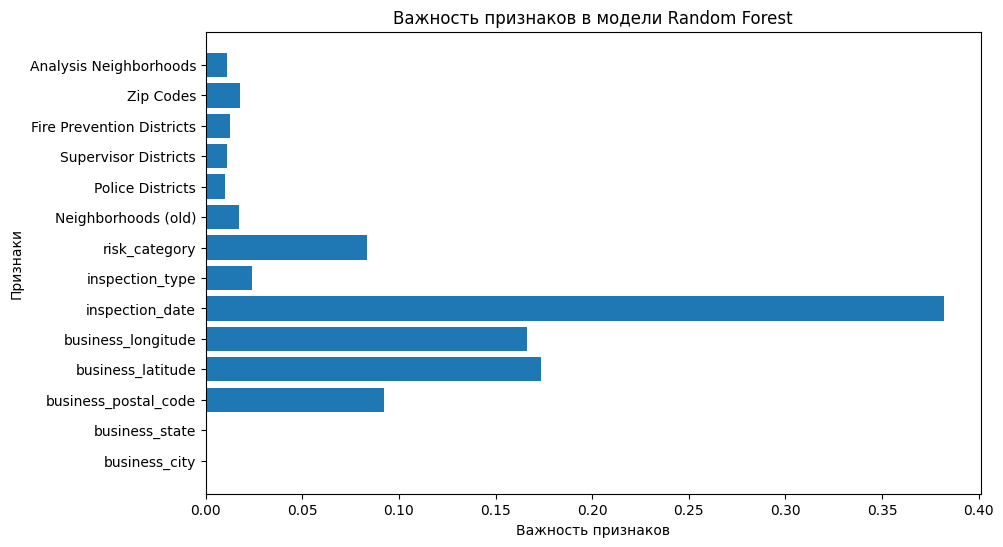

In [124]:
print("\nСравнение моделей:")
print(f"Decision Tree - MSE: {mse_dt}, R2: {r2_dt}")
print(f"Random Forest - MSE: {mse_rf}, R2: {r2_rf}")


feature_importances = rf_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.xlabel('Важность признаков')
plt.ylabel('Признаки')
plt.title('Важность признаков в модели Random Forest')
plt.show()

### Выводы

Для оценки качества моделей Random Forest и Decision Tree использовались метрики MSE (среднеквадратичная ошибка) и R² (коэффициент детерминации). Random Forest показал результаты: MSE = 15.36, R² = 0.71, что означает, что модель объясняет 71% дисперсии данных. Decision Tree работал хуже: MSE = 20.21, R² = 0.62, что говорит о переобучении или недостатке информации в данных.

Вывод: Random Forest справляется неплохо, но данный результат можно и улучшить — например, добавить признаки или настройки гиперпараметров. Decision Tree оказался не лучшим выбором для этой задачи. Для улучшения результатов стоит проверить данные на выбросы и попробовать другие алгоритмы, например, градиентный бустинг.